
<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2e75b6 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
<h1 style="font-size: 2.5em; margin-bottom: 10px;">🧹 Olist E-Commerce</h1>
<h2 style="font-weight: 300; font-size: 1.5em; margin-bottom: 20px;">Data Cleaning Notebook</h2>
<p style="font-size: 1.1em; opacity: 0.85;" >Step 4 of 6 · integration → EDA → Cleaning → <b>Feature Engineering</b> → Preprocessing → Modeling</p>
</div>

---

## What This Notebook Does

| Step | Action | Reason |
|---|---|---|
| **1** | Imports & load data | Start fresh from merged CSV |
| **2** | Snapshot before cleaning | Know what we started with |
| **3** | Filter to delivered orders | Non-delivered have no review/delivery date |
| **4** | Drop high-missing columns | 58–88% missing, not usable |
| **5** | Drop missing delivery dates | True data quality errors post-filter |
| **6** | Drop missing review scores | Can't model without the target |
| **7** | Impute product dimensions | Category-level median — smarter than global |
| **8** | Fill missing categories | Replace with 'unknown' |
| **9** | Drop remaining null rows | Payment, seller, price — very few |
| **10** | Cap price/freight outliers | Prevent extreme values from distorting models |
| **11** | Validate & save | Final check + export clean CSV |


## Step 1 — Load Clean Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('olist_clean.csv')

# Re-parse datetime columns
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} -> {df['order_purchase_timestamp'].max().date()}")
df.head(3)

Loaded: 114,850 rows x 38 columns
Date range: 2016-10-03 -> 2018-08-29


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares


## Step 2 — Delivery Features

We break the order lifecycle into distinct time segments. Each segment captures a different part of the fulfilment chain:

```
Purchase → Approval → Carrier Pickup → Customer Delivery
    |______________|_________________|___________________|
     approval_days    carrier_days        last_mile_days
    |___________________________________________________|
                      delivery_days (total)
```


Delivery feature stats:
       delivery_days  approval_days  carrier_days  last_mile_days
count      114850.00      114835.00     114835.00       114850.00
mean           11.98          10.43          2.36            8.71
std             9.37          20.93          3.51            8.54
min             0.00           0.00          0.00            0.00
25%             6.00           0.22          0.00            4.00
50%            10.00           0.35          1.00            7.00
75%            15.00          14.95          3.00           11.00
max           208.00         741.44        125.00          205.00


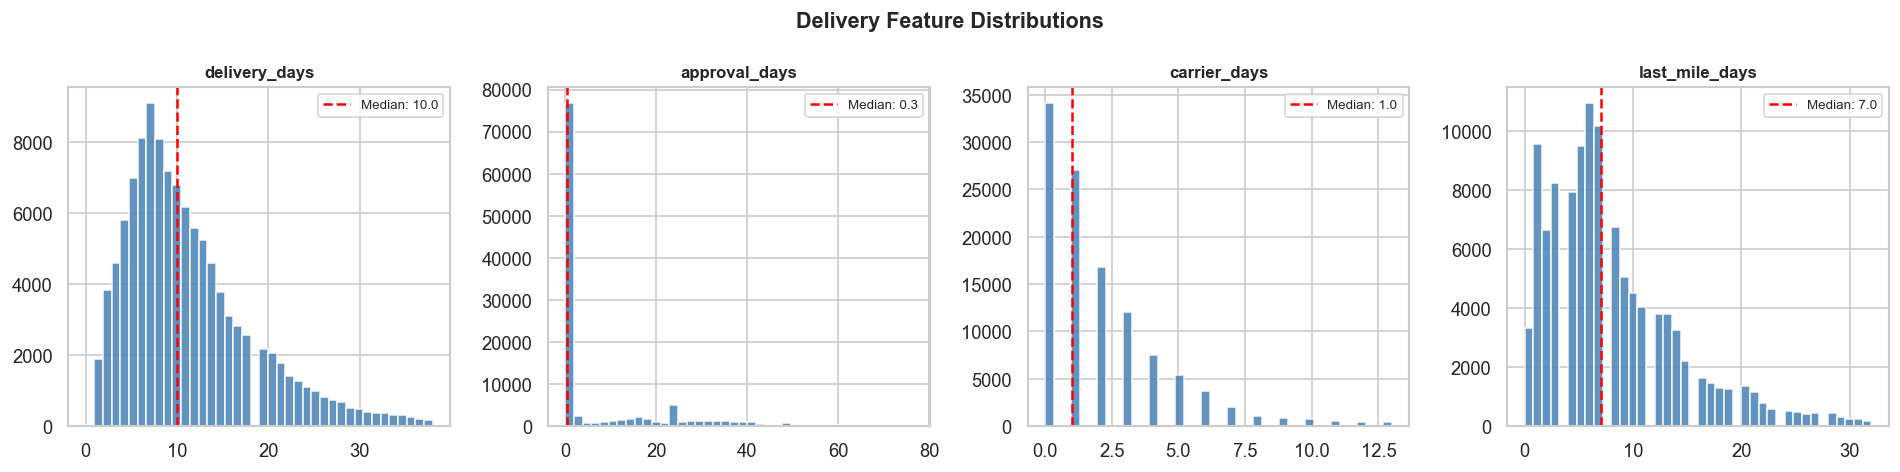

In [12]:
# Total delivery time: purchase → customer delivery
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Time to approval: purchase → payment approved
df['approval_days'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / 3600  # in hours (usually < 24h)

# Time to carrier: approval → picked up by carrier
df['carrier_days'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.days

# Last mile: carrier pickup → customer delivery
df['last_mile_days'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.days

# Clip negatives to 0 (data entry errors)
for col in ['delivery_days', 'carrier_days', 'last_mile_days']:
    df[col] = df[col].clip(lower=0)
df['approval_days'] = df['approval_days'].clip(lower=0)

print("Delivery feature stats:")
print(df[['delivery_days', 'approval_days', 'carrier_days', 'last_mile_days']].describe().round(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['delivery_days', 'approval_days', 'carrier_days', 'last_mile_days']):
    data = df[col].dropna()
    data = data[data <= data.quantile(0.98)]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Delivery Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3 — Delay Features

The EDA proved delivery delay is the **#1 driver of customer satisfaction**. We engineer three versions:
- `delay_days` — continuous (negative = early, positive = late)
- `is_late` — binary flag
- `delay_severity` — ordinal bucket (useful for tree models and interpretation)


Delay feature summary:
  Mean delay:      -12.08 days
  Median delay:    -13.00 days
  % Late orders:   6.4%
  % Early orders:  92.3%

Delay severity distribution:
delay_severity
very_early         91344
on_time            16143
slightly_late       4172
moderately_late     1642
very_late           1549


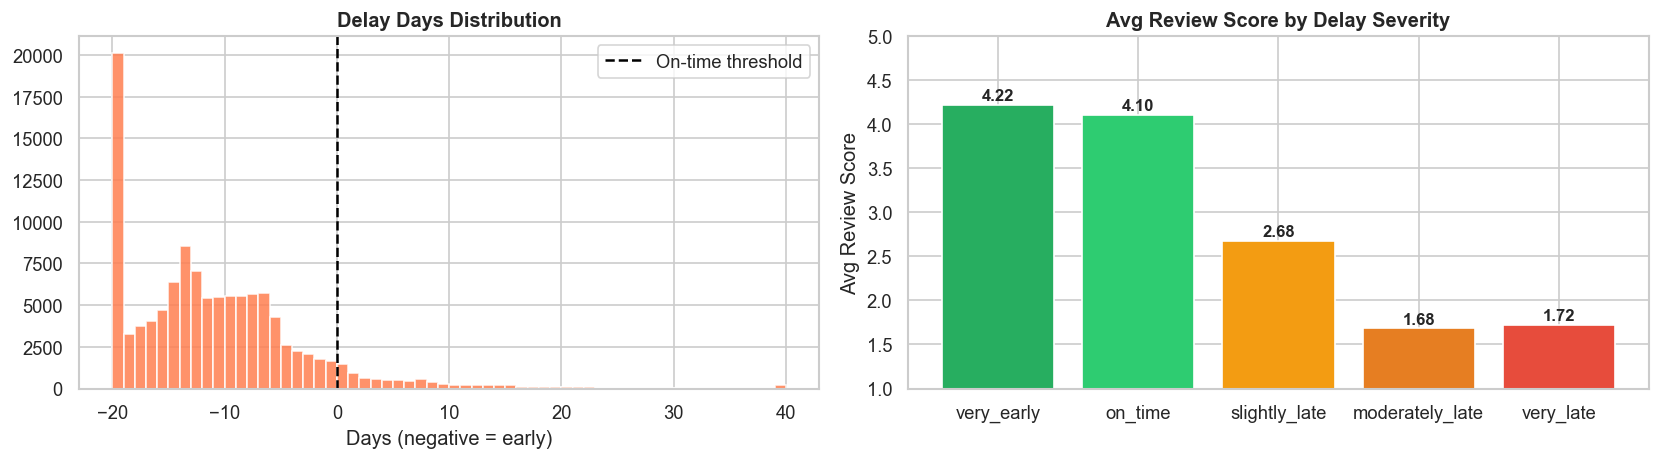

In [13]:
# Continuous delay: positive = late, negative = early
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# Binary late flag
df['is_late'] = (df['delay_days'] > 0).astype(int)

# Ordinal severity bucket
df['delay_severity'] = pd.cut(
    df['delay_days'],
    bins=[-999, -7, 0, 7, 14, 999],
    labels=['very_early', 'on_time', 'slightly_late', 'moderately_late', 'very_late']
)

print("Delay feature summary:")
print(f"  Mean delay:      {df['delay_days'].mean():.2f} days")
print(f"  Median delay:    {df['delay_days'].median():.2f} days")
print(f"  % Late orders:   {df['is_late'].mean()*100:.1f}%")
print(f"  % Early orders:  {(df['delay_days'] < 0).mean()*100:.1f}%")
print()
print("Delay severity distribution:")
print(df['delay_severity'].value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Delay distribution
delay_clipped = df['delay_days'].clip(-20, 40)
axes[0].hist(delay_clipped, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='On-time threshold')
axes[0].set_title('Delay Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days (negative = early)')
axes[0].legend()

# Severity vs avg review
sev_review = df.groupby('delay_severity', observed=True)['review_score'].mean()
colors_sev = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[1].bar(sev_review.index, sev_review.values, color=colors_sev, edgecolor='white')
axes[1].set_ylim(1, 5)
axes[1].set_title('Avg Review Score by Delay Severity', fontweight='bold')
axes[1].set_ylabel('Avg Review Score')
for i, v in enumerate(sev_review.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 4 — Price & Payment Features

Price, freight, and payment value are all right-skewed. We apply `log1p()` transformation to normalise them, and engineer ratio features that capture relative costs.


Price feature stats:
        log_price  log_freight  freight_ratio  margin_proxy
count  114850.000   114850.000     114850.000    114850.000
mean        4.330        2.890          0.214        97.038
std         0.900        0.520          0.129       144.624
min         0.615        0.000          0.000       -80.108
25%         3.711        2.645          0.119        24.410
50%         4.329        2.850          0.189        55.980
75%         4.897        3.098          0.282       111.120
max         7.091        4.664          0.963      1188.000


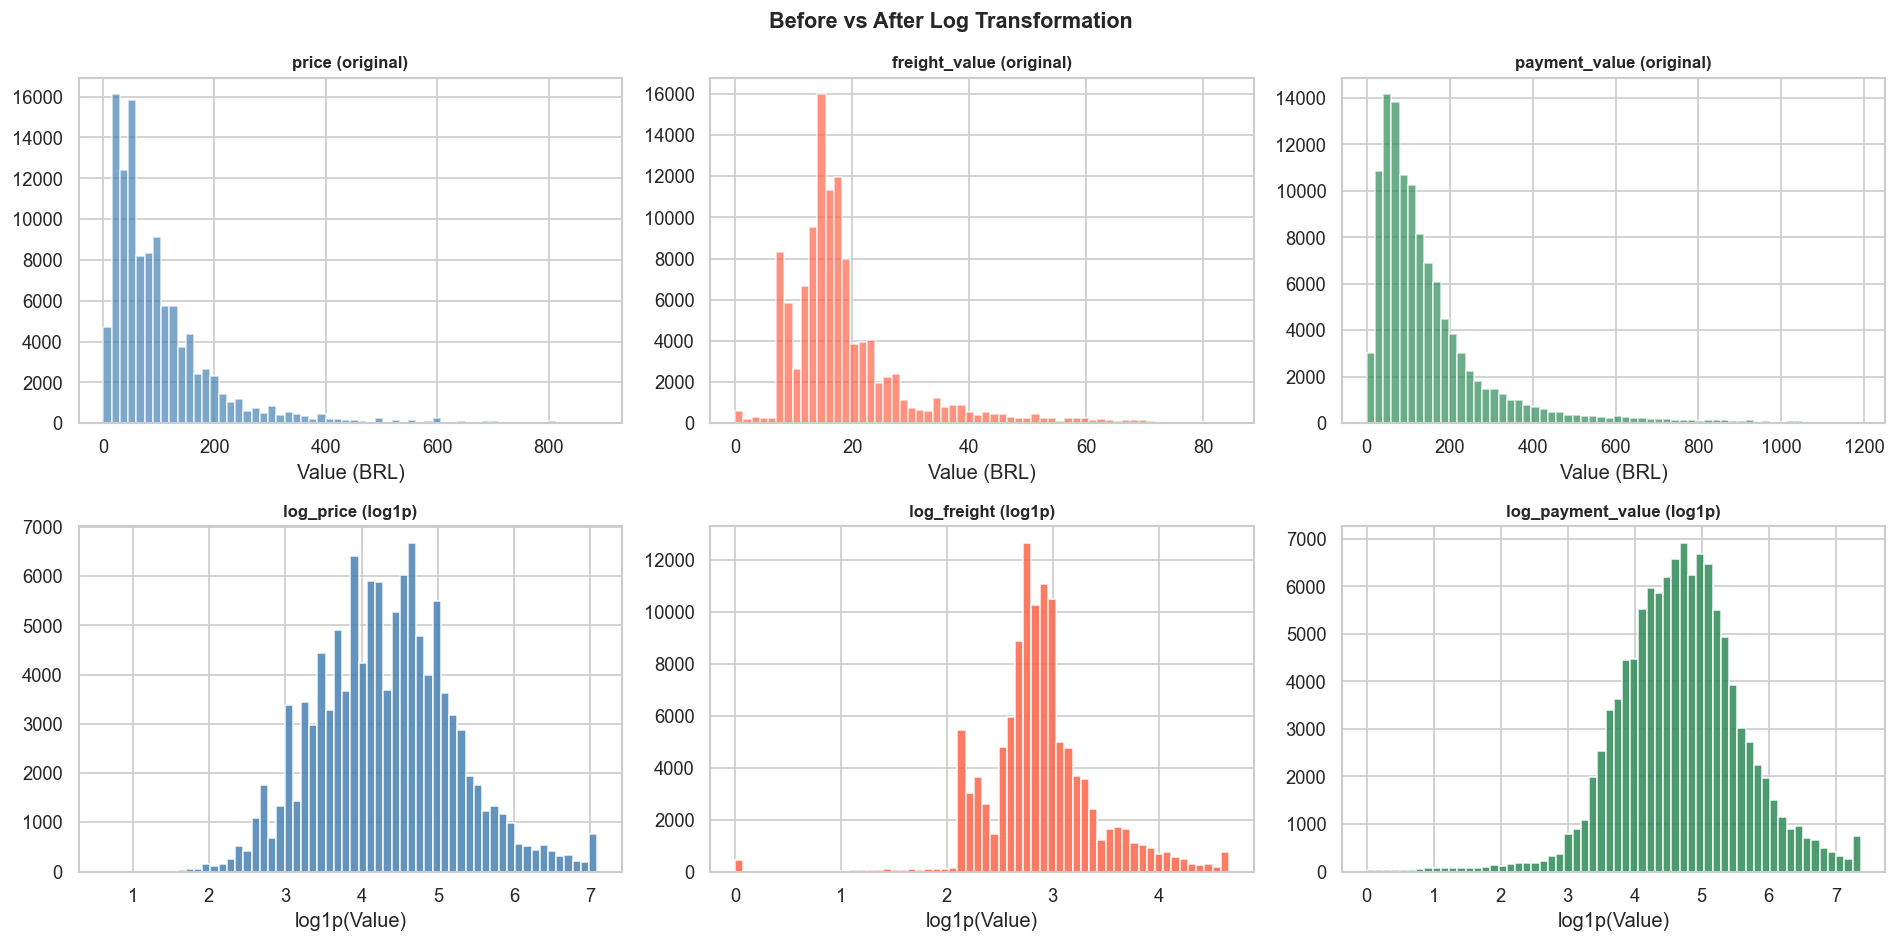

In [14]:
# Log transformations (log1p handles zeros safely)
df['log_price']         = np.log1p(df['price'])
df['log_freight']       = np.log1p(df['freight_value'])
df['log_payment_value'] = np.log1p(df['payment_value'])
df['log_weight']        = np.log1p(df['product_weight_g'])

# Ratio features
df['freight_ratio']  = df['freight_value'] / (df['price'] + df['freight_value'])
df['margin_proxy']   = df['price'] - df['freight_value']
df['freight_per_kg'] = df['freight_value'] / (df['product_weight_g'] / 1000 + 0.001)

print("Price feature stats:")
print(df[['log_price', 'log_freight', 'freight_ratio', 'margin_proxy']].describe().round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

pairs = [
    ('price',         'log_price',         'steelblue'),
    ('freight_value', 'log_freight',        'tomato'),
    ('payment_value', 'log_payment_value',  'seagreen'),
]

for i, (orig, log_col, color) in enumerate(pairs):
    # Original
    d = df[orig].dropna()
    axes[0, i].hist(d[d <= d.quantile(0.99)], bins=60,
                    color=color, edgecolor='white', alpha=0.7)
    axes[0, i].set_title(f'{orig} (original)', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('Value (BRL)')

    # Log transformed
    axes[1, i].hist(df[log_col].dropna(), bins=60,
                    color=color, edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{log_col} (log1p)', fontsize=10, fontweight='bold')
    axes[1, i].set_xlabel('log1p(Value)')

plt.suptitle('Before vs After Log Transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Time Features

When an order is placed carries significant signal — shopping patterns differ by hour, day, month, and season. We also flag Black Friday (November) separately since the EDA showed a clear spike.


Time feature value counts:
  Weekend orders:        22.7%
  Peak hours orders:     53.5%
  Black Friday month:    7.7%


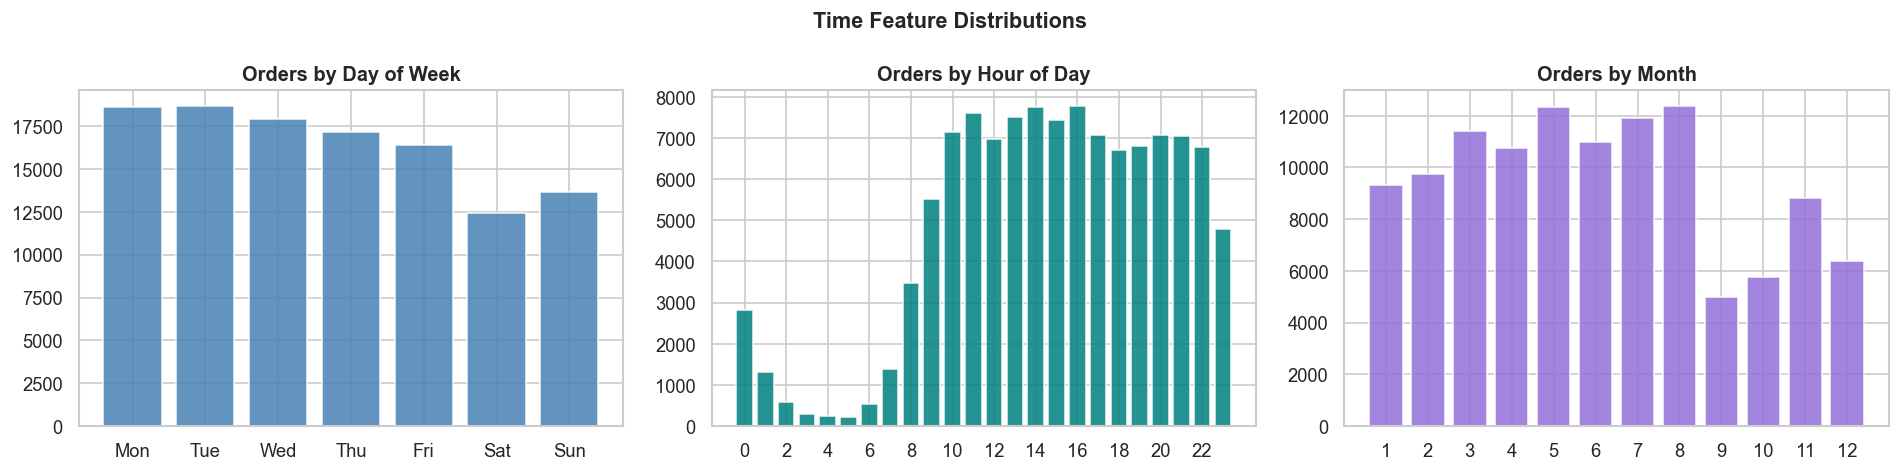

In [15]:
df['purchase_hour']    = df['order_purchase_timestamp'].dt.hour
df['purchase_dow']     = df['order_purchase_timestamp'].dt.dayofweek  # 0=Monday
df['purchase_month']   = df['order_purchase_timestamp'].dt.month
df['purchase_quarter'] = df['order_purchase_timestamp'].dt.quarter
df['purchase_year']    = df['order_purchase_timestamp'].dt.year
df['is_weekend']       = (df['purchase_dow'] >= 5).astype(int)
df['is_black_friday']  = (df['purchase_month'] == 11).astype(int)

# Business hours flag (10:00-20:00 weekdays = peak shopping window from EDA)
df['is_peak_hours'] = (
    (df['purchase_hour'] >= 10) &
    (df['purchase_hour'] <= 20) &
    (df['is_weekend'] == 0)
).astype(int)

print("Time feature value counts:")
print(f"  Weekend orders:        {df['is_weekend'].mean()*100:.1f}%")
print(f"  Peak hours orders:     {df['is_peak_hours'].mean()*100:.1f}%")
print(f"  Black Friday month:    {df['is_black_friday'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df['purchase_dow'].value_counts().sort_index()
axes[0].bar(dow_names, dow_counts.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Orders by Day of Week', fontweight='bold')

hour_counts = df['purchase_hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Orders by Hour of Day', fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))

month_counts = df['purchase_month'].value_counts().sort_index()
axes[2].bar(month_counts.index, month_counts.values, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[2].set_title('Orders by Month', fontweight='bold')
axes[2].set_xticks(range(1, 13))

plt.suptitle('Time Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Geography Features

The EDA showed that seller-customer geographic mismatch drives up freight costs and delivery times. We create features that capture this distance signal without needing actual coordinates.


Geography feature summary:
  Same state orders:           36.1%
  Same region orders:          62.4%
  SP seller -> remote:         11.9%


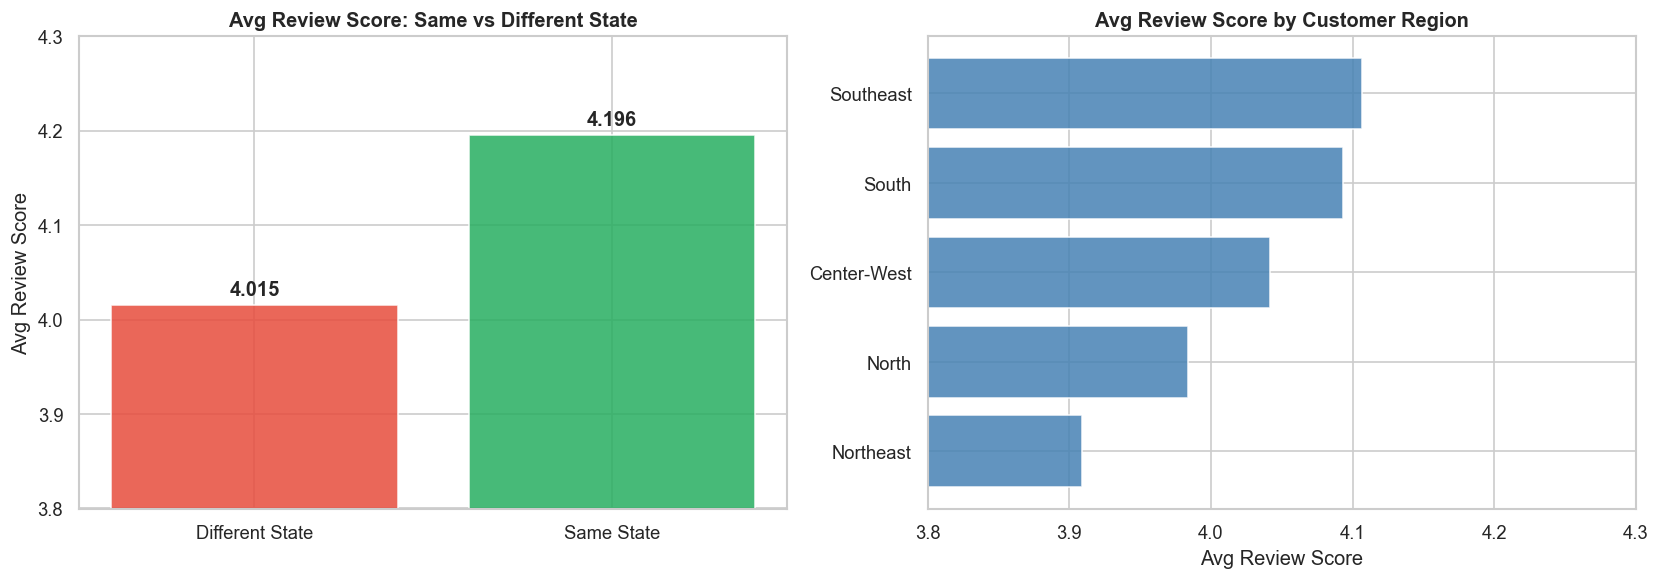

In [16]:
# Same state flag — strongest simple distance proxy
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

# Region mapping for Brazil
region_map = {
    'SP': 'Southeast', 'RJ': 'Southeast', 'MG': 'Southeast', 'ES': 'Southeast',
    'RS': 'South',     'SC': 'South',     'PR': 'South',
    'BA': 'Northeast', 'PE': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast',
    'PB': 'Northeast', 'RN': 'Northeast', 'AL': 'Northeast', 'SE': 'Northeast', 'PI': 'Northeast',
    'PA': 'North',     'AM': 'North',     'RO': 'North',     'AC': 'North',
    'AP': 'North',     'RR': 'North',     'TO': 'North',
    'GO': 'Center-West', 'MT': 'Center-West', 'MS': 'Center-West', 'DF': 'Center-West'
}

df['customer_region'] = df['customer_state'].map(region_map).fillna('Other')
df['seller_region']   = df['seller_state'].map(region_map).fillna('Other')
df['same_region']     = (df['customer_region'] == df['seller_region']).astype(int)

# Cross-region flag: SP seller to non-Southeast customer (most common mismatch)
df['sp_seller_remote_customer'] = (
    (df['seller_state'] == 'SP') &
    (df['customer_region'].isin(['North', 'Northeast', 'Center-West']))
).astype(int)

print("Geography feature summary:")
print(f"  Same state orders:           {df['same_state'].mean()*100:.1f}%")
print(f"  Same region orders:          {df['same_region'].mean()*100:.1f}%")
print(f"  SP seller -> remote:         {df['sp_seller_remote_customer'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

same_review = df.groupby('same_state')['review_score'].mean()
axes[0].bar(['Different State', 'Same State'], same_review.values,
            color=['#e74c3c', '#27ae60'], edgecolor='white', alpha=0.85)
axes[0].set_ylim(3.8, 4.3)
axes[0].set_title('Avg Review Score: Same vs Different State', fontweight='bold')
axes[0].set_ylabel('Avg Review Score')
for i, v in enumerate(same_review.values):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')

region_review = df.groupby('customer_region')['review_score'].mean().sort_values()
axes[1].barh(region_review.index, region_review.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlim(3.8, 4.3)
axes[1].set_title('Avg Review Score by Customer Region', fontweight='bold')
axes[1].set_xlabel('Avg Review Score')

plt.tight_layout()
plt.show()

## Step 7 — Product Features

Product dimensions and weight affect both freight cost and delivery handling. We combine them into a volume feature and create a categorical size bucket.


Product feature stats:
       product_volume_cm3  log_volume  log_weight
count           114850.00   114850.00   114850.00
mean             15271.59        8.85        6.70
std              23400.99        1.28        1.33
min                168.00        5.13        0.00
25%               2856.00        7.96        5.71
50%               6561.00        8.79        6.55
75%              18375.00        9.82        7.50
max             296208.00       12.60       10.61

Size category distribution:
size_category
light         32154
medium        36905
heavy         31548
very_heavy    14235


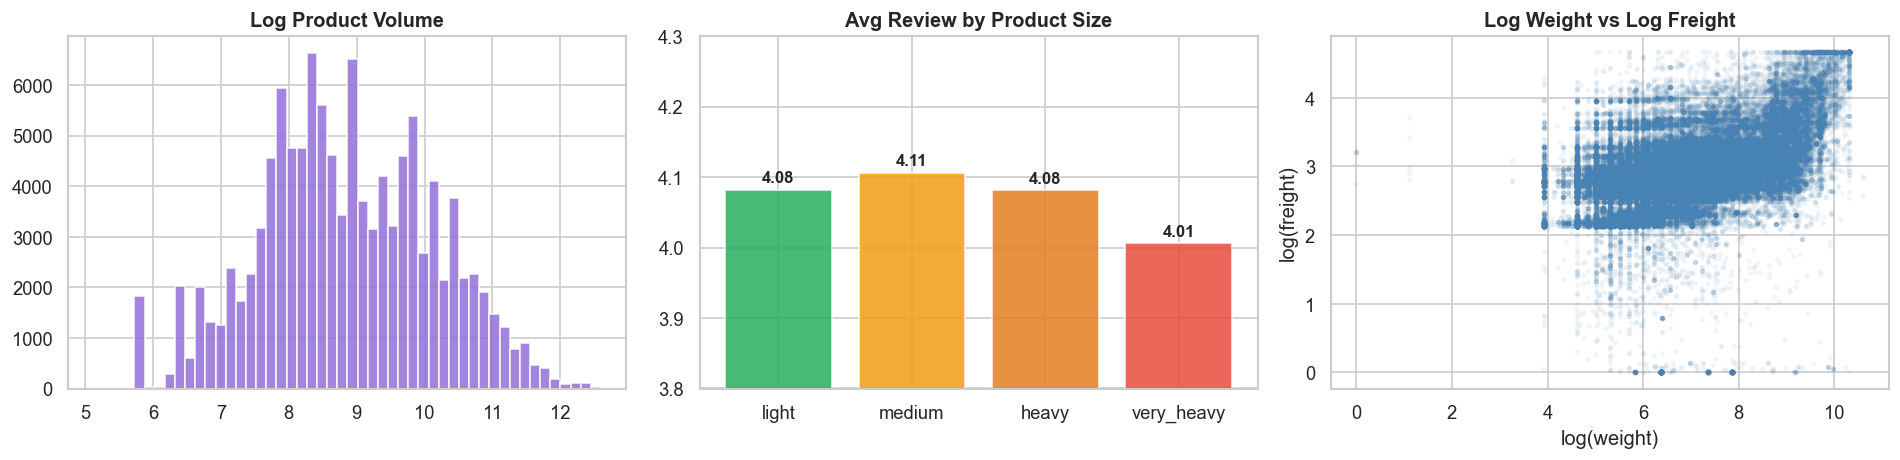

In [17]:
# Product volume
df['product_volume_cm3'] = (
    df['product_length_cm'] *
    df['product_height_cm'] *
    df['product_width_cm']
)

# Log volume (skewed)
df['log_volume'] = np.log1p(df['product_volume_cm3'])

# Size category based on weight
df['size_category'] = pd.cut(
    df['product_weight_g'],
    bins=[0, 300, 1000, 5000, 999999],
    labels=['light', 'medium', 'heavy', 'very_heavy']
)

# Photos ratio: more photos = better listing quality
df['photos_per_desc_char'] = df['product_photos_qty'] / (df['product_description_lenght'] + 1)

print("Product feature stats:")
print(df[['product_volume_cm3', 'log_volume', 'log_weight']].describe().round(2))
print()
print("Size category distribution:")
print(df['size_category'].value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['log_volume'].dropna(), bins=50, color='mediumpurple',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Log Product Volume', fontweight='bold')

size_review = df.groupby('size_category', observed=True)['review_score'].mean()
axes[1].bar(size_review.index, size_review.values,
            color=['#27ae60', '#f39c12', '#e67e22', '#e74c3c'], edgecolor='white', alpha=0.85)
axes[1].set_ylim(3.8, 4.3)
axes[1].set_title('Avg Review by Product Size', fontweight='bold')
for i, v in enumerate(size_review.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

axes[2].scatter(df['log_weight'].dropna(), df['log_freight'].dropna(),
                alpha=0.05, s=5, color='steelblue')
axes[2].set_title('Log Weight vs Log Freight', fontweight='bold')
axes[2].set_xlabel('log(weight)')
axes[2].set_ylabel('log(freight)')

plt.tight_layout()
plt.show()

## Step 8 — Seller Aggregate Features

> ⚠️ **Leakage Warning:** Seller aggregate features (avg review, on-time rate) must be computed on the **training set only**, then merged into the test set. Computing them on the full dataset leaks future information.

For now, we compute them on the full dataset to create the feature columns. The train/test split with proper leakage prevention happens in the Preprocessing notebook.


Seller aggregate features created:
       seller_order_count  seller_avg_review  seller_on_time_rate  \
count          114850.000         114850.000           114850.000   
mean              442.685              4.081                0.936   
std               584.804              0.369                0.057   
min                 1.000              1.000                0.000   
25%                59.000              3.929                0.915   
50%               179.000              4.110                0.946   
75%               545.000              4.277                0.967   
max              2093.000              5.000                1.000   

       seller_avg_delivery  
count           114850.000  
mean                11.979  
std                  3.353  
min                  1.000  
25%                  9.921  
50%                 11.751  
75%                 13.718  
max                189.000  


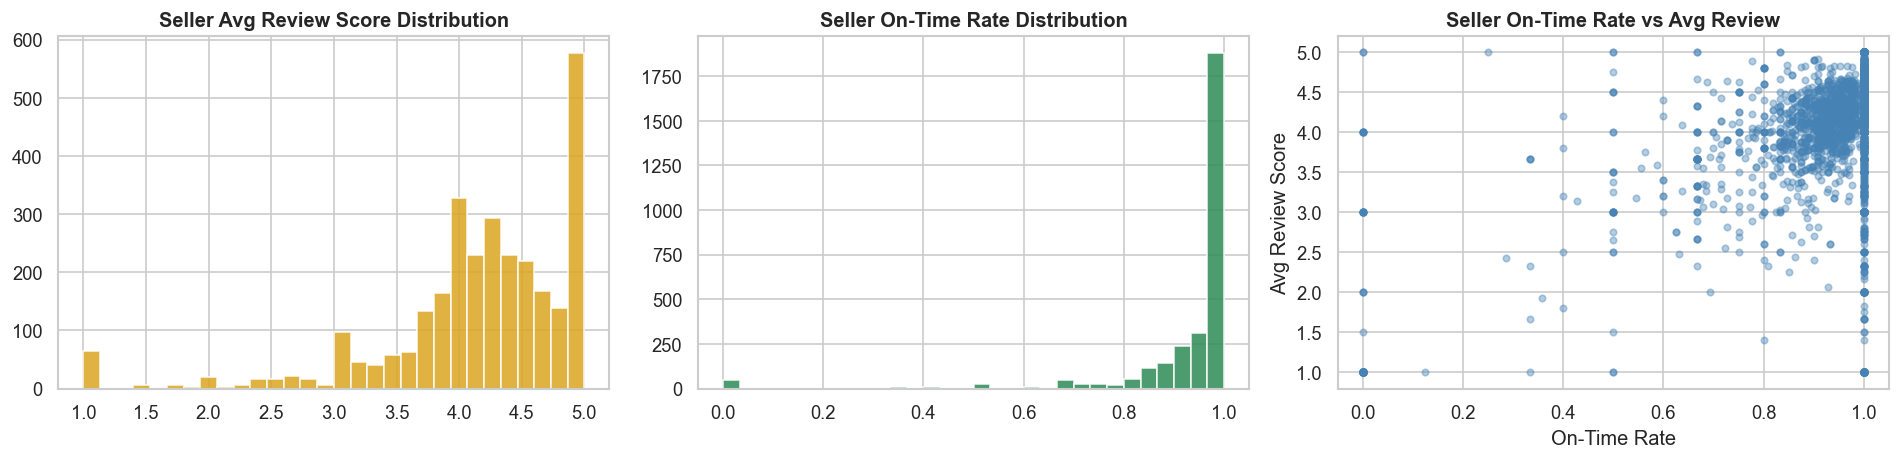

In [18]:
# Compute seller aggregates on full dataset
# (will be recomputed properly on training fold in preprocessing)
seller_agg = df.groupby('seller_id').agg(
    seller_order_count      = ('order_id',     'count'),
    seller_avg_review       = ('review_score', 'mean'),
    seller_avg_delivery     = ('delivery_days','mean'),
    seller_avg_freight      = ('freight_value','mean'),
    seller_on_time_rate     = ('is_late',       lambda x: 1 - x.mean()),
    seller_avg_price        = ('price',         'mean'),
).reset_index()

df = df.merge(seller_agg, on='seller_id', how='left')

print("Seller aggregate features created:")
print(df[['seller_order_count', 'seller_avg_review',
          'seller_on_time_rate', 'seller_avg_delivery']].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(seller_agg['seller_avg_review'].dropna(), bins=30,
             color='goldenrod', edgecolor='white', alpha=0.85)
axes[0].set_title('Seller Avg Review Score Distribution', fontweight='bold')

axes[1].hist(seller_agg['seller_on_time_rate'].dropna(), bins=30,
             color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Seller On-Time Rate Distribution', fontweight='bold')

axes[2].scatter(seller_agg['seller_on_time_rate'],
                seller_agg['seller_avg_review'],
                alpha=0.4, s=15, color='steelblue')
axes[2].set_title('Seller On-Time Rate vs Avg Review', fontweight='bold')
axes[2].set_xlabel('On-Time Rate')
axes[2].set_ylabel('Avg Review Score')

plt.tight_layout()
plt.show()

## Step 9 — Target Variable

We create a binary target variable for classification: `is_satisfied = 1` if `review_score >= 4`, else `0`.

**Why binary instead of multi-class (1–5)?**
- The EDA showed a bimodal distribution — mostly 5s and 1s
- Binary classification is simpler, more robust, and easier to evaluate
- The business question is clear: "Will this customer be satisfied?"


Satisfied (score >= 4): 76.8%
Dissatisfied (score < 4): 23.2%
Class ratio: 3.31:1


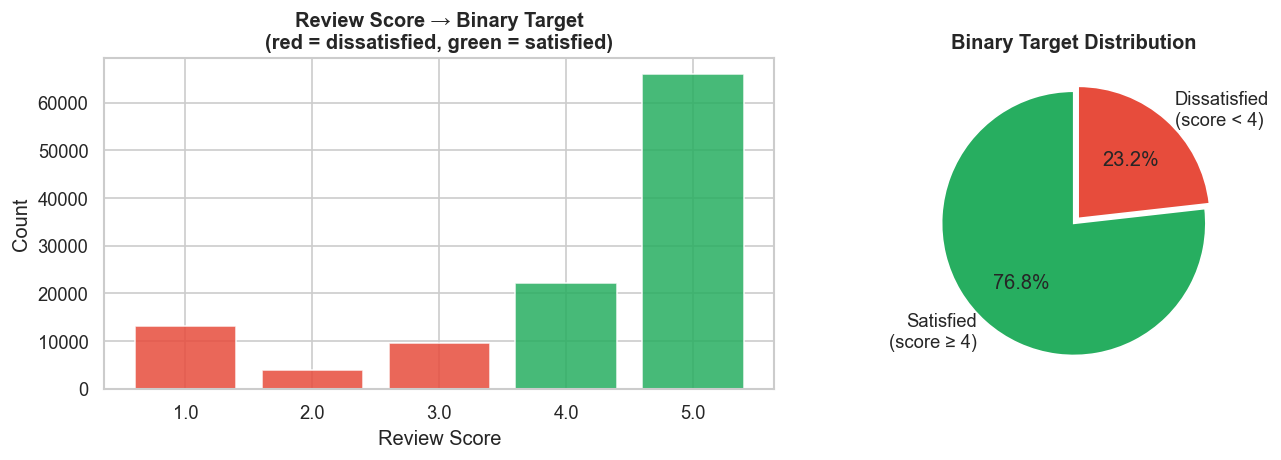

In [19]:
import matplotlib.pyplot as plt

# Create binary target
df['is_satisfied'] = (df['review_score'] >= 4).astype(int)

# Calculate percentages
satisfied = df['is_satisfied'].mean() * 100
print(f"Satisfied (score >= 4): {satisfied:.1f}%")
print(f"Dissatisfied (score < 4): {100 - satisfied:.1f}%")
print(f"Class ratio: {satisfied / (100 - satisfied):.2f}:1")

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: Review score → binary target ---
score_counts = df['review_score'].value_counts().sort_index()
colors = ['#e74c3c', '#e74c3c', '#e74c3c', '#27ae60', '#27ae60']

axes[0].bar(
    score_counts.index.astype(str),
    score_counts.values,
    color=colors,
    edgecolor='white',
    alpha=0.85
)

axes[0].set_title(
    'Review Score → Binary Target\n(red = dissatisfied, green = satisfied)',
    fontweight='bold'
)
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

# --- Plot 2: Binary target distribution ---
target_counts = df['is_satisfied'].value_counts()

axes[1].pie(
    target_counts.values,
    labels=['Satisfied\n(score ≥ 4)', 'Dissatisfied\n(score < 4)'],
    autopct='%1.1f%%',
    colors=['#27ae60', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05)
)

axes[1].set_title('Binary Target Distribution', fontweight='bold')

# Layout
plt.tight_layout()
plt.show()

## Step 10 — Feature Summary & Save

Final overview of all engineered features before saving. We also drop columns that are either identifiers, raw datetime columns, or will cause leakage in modeling.


In [20]:
# ── Drop columns not needed for modeling ─────────────────────────────────────
drop_cols = [
    # Identifiers
    'order_id', 'customer_id', 'customer_unique_id', 'product_id',
    'seller_id', 'review_id',
    # Raw datetime (already extracted into features)
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp',
    # Raw target (replaced by is_satisfied)
    'review_score',
    # Order status (always 'delivered' after cleaning)
    'order_status',
    # Raw string names replaced by engineered features
    'product_category_name',
]

df_feat = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"Final feature set: {df_feat.shape[1]} columns, {df_feat.shape[0]:,} rows")
print()

# ── Feature summary table ─────────────────────────────────────────────────────
feature_groups = {
    'Delivery':  ['delivery_days', 'approval_days', 'carrier_days', 'last_mile_days'],
    'Delay':     ['delay_days', 'is_late', 'delay_severity'],
    'Price':     ['log_price', 'log_freight', 'log_payment_value', 'freight_ratio', 'margin_proxy'],
    'Time':      ['purchase_hour', 'purchase_dow', 'purchase_month', 'purchase_quarter',
                  'is_weekend', 'is_black_friday', 'is_peak_hours'],
    'Geography': ['same_state', 'same_region', 'customer_region', 'seller_region',
                  'sp_seller_remote_customer'],
    'Product':   ['product_volume_cm3', 'log_volume', 'log_weight', 'size_category',
                  'product_photos_qty'],
    'Seller':    ['seller_order_count', 'seller_avg_review', 'seller_on_time_rate',
                  'seller_avg_delivery', 'seller_avg_freight'],
    'Target':    ['is_satisfied'],
}

for group, cols in feature_groups.items():
    existing = [c for c in cols if c in df_feat.columns]
    print(f"  {group:12s}: {existing}")

Final feature set: 59 columns, 114,850 rows

  Delivery    : ['delivery_days', 'approval_days', 'carrier_days', 'last_mile_days']
  Delay       : ['delay_days', 'is_late', 'delay_severity']
  Price       : ['log_price', 'log_freight', 'log_payment_value', 'freight_ratio', 'margin_proxy']
  Time        : ['purchase_hour', 'purchase_dow', 'purchase_month', 'purchase_quarter', 'is_weekend', 'is_black_friday', 'is_peak_hours']
  Geography   : ['same_state', 'same_region', 'customer_region', 'seller_region', 'sp_seller_remote_customer']
  Product     : ['product_volume_cm3', 'log_volume', 'log_weight', 'size_category', 'product_photos_qty']
  Seller      : ['seller_order_count', 'seller_avg_review', 'seller_on_time_rate', 'seller_avg_delivery', 'seller_avg_freight']
  Target      : ['is_satisfied']


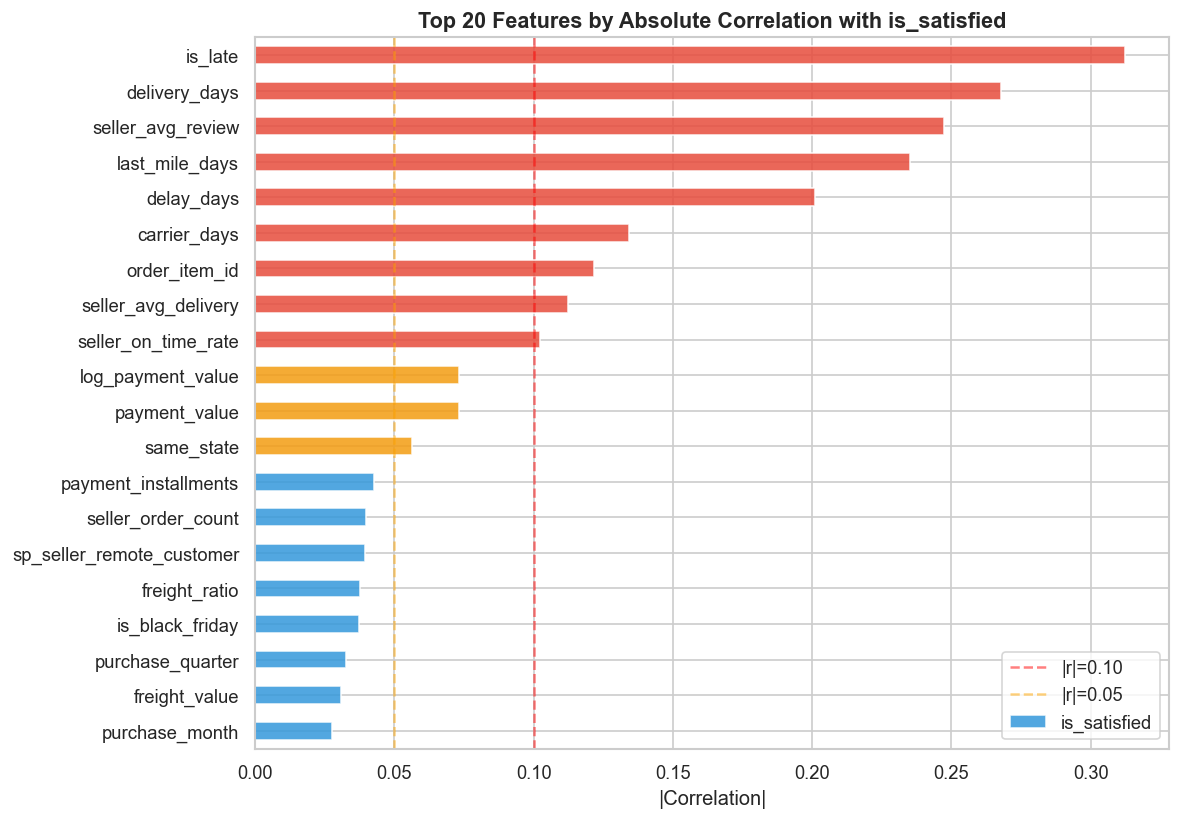


Top 10 features by correlation with target:
is_late                0.3124
delivery_days          0.2679
seller_avg_review      0.2472
last_mile_days         0.2353
delay_days             0.2008
carrier_days           0.1343
order_item_id          0.1217
seller_avg_delivery    0.1123
seller_on_time_rate    0.1021
log_payment_value      0.0733


In [21]:
# ── Quick correlation of new features vs target ───────────────────────────────
numeric_feats = df_feat.select_dtypes(include=[np.number]).columns.tolist()
numeric_feats = [c for c in numeric_feats if c != 'is_satisfied']

corr_with_target = df_feat[numeric_feats + ['is_satisfied']].corr()['is_satisfied'].drop('is_satisfied')
corr_with_target = corr_with_target.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0.1 else '#f39c12' if v > 0.05 else '#3498db'
          for v in corr_with_target.values]
corr_with_target[::-1].plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_title('Top 20 Features by Absolute Correlation with is_satisfied',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlation|')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='|r|=0.10')
ax.axvline(0.05, color='orange', linestyle='--', alpha=0.5, label='|r|=0.05')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 features by correlation with target:")
print(corr_with_target.head(10).round(4).to_string())

In [22]:
# ── Final null check ──────────────────────────────────────────────────────────
remaining_nulls = df_feat.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("No nulls in any column")
else:
    print("Remaining nulls (will be handled in preprocessing):")
    print(remaining_nulls.to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
df_feat.to_csv('olist_features.csv', index=False)

print(f"\n Saved: olist_features.csv")
print(f"   Shape: {df_feat.shape[0]:,} rows x {df_feat.shape[1]} columns")
print(f"\n📌 Next step: Preprocessing notebook (olist_features.csv -> train/test split + encoding)")

Remaining nulls (will be handled in preprocessing):
approval_days    15
carrier_days     15
size_category     8

 Saved: olist_features.csv
   Shape: 114,850 rows x 59 columns

📌 Next step: Preprocessing notebook (olist_features.csv -> train/test split + encoding)
